# Machine Learning in Python

- Tools: scikit-learn (`sklearn`)
    - Data Partitioning
    - Feature Engineering/Selection
    - Model Selection
    - Model Assessment
    
 [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/COGS108/Lectures-Sp26/blob/main/19-ML-notebook.ipynb)


For more reading on scikit-learn (`sklearn`) and machine learning in Python: https://scikit-learn.org/stable/index.html

# Machine Learning: General Steps

1. Data Partitioning
2. Feature Selection
3. Fit a model
4. Model Assessment

## Setup

In [1]:
# import ds/plotting packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

### SVM: Support Vector Machines

- simple & interpretable machine learning model
- based in linear regression
- classification task
- supervized
    - input: labeled training data
    - model determines hyperplane that best discriminates between categories

### SVM: Tuning Parameters
- **regularization** parameter `C`
    - determines how the decision boundary is drawn
    - values >> 1 are hard margin, try to draw perfect boundary, not good for highly overlapping classes, may overfit noise but will do the best possible job when classes are clearly seperable
    - values << 1 are soft margin, higher tolerance for misclassification (won't do the best possible job when classes are distinct) but more robustness to overlapping classes and noisy examples
- **kernel** parameter `kernel`
    - specifies how to model & transform data
    - can be linear or non linear
    - RBF is very general purpose non linear
    

For more reading on SVMs using `sklearn`: https://scikit-learn.org/stable/modules/svm.html

## Performance Assessment

- for continuous prediction / regression tasks
    - MSE, RMSE, MAE
- for classification tasks
    - Accuracy
    - TP, TN, FP, FN
    - Precision, Recall, AUC
    

![confusion matrix](https://miro.medium.com/max/924/1*7EYylA6XlXSGBCF77j_rOA.png)

![sensitivity recell](https://miro.medium.com/max/878/1*Ub0nZTXYT8MxLzrz0P7jPA.png)

**Accuracy** - What % were predicted correctly?  
**Sensitivity (Recall)** - Of those that were positives, what % were predicted to be positive?  ; $\frac {TP}{(TP + FN)}$  
**Specificity** - Of those that were actually negatives, what % were predicted to be negative?  $\frac {TN}{(TN + FP)}$

**Precision (Positive Predictive Value, PPV)** = $\frac {TP}{(TP + FP)}$

- probability that predicted positive truly is positive

## A short quiz --- This counts towards your class participation check-ins!


Click this link:

https://docs.google.com/forms/d/e/1FAIpQLScI2vt2rW7rjRVQXKEQLuC68RICLUXa-Vyo5TXcPYtGTW7aHw/viewform?usp=sharing&ouid=101992505427251219835



## Feature engineering
One thing we didn't talk about is how you need to engineer features for NON-text kinds of inputs

In general this is a huge topic that I will try condense for you into two bullet points.

- If your data has different kinds of continuous variables, and especially if some of those variables tend to be big numbers (distance to the moon in meters) and some tend to be small numbers (the earths mass as a fraction of the earth's mass), then you need to STANDARDIZE those two variables to have roughly the same magnitude. If you don't then the ML system may think that the large magnitude variable is more predictive than the small magnitude variable.  See this link https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing-scaler
- If your data has categorical variables that do not have a natural order to them (red is not greater than blue), then you need to ONE-HOT encode those categorical variables.  Otherwise your ML system will think that red is greater than blue and that can make for some bad predictions.  See this link https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing-categorical-features

OK lets talk about how to do things with the non text input...

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd

%matplotlib inline

# lets get some 🐧 data to work with
df = sns.load_dataset('penguins').dropna()

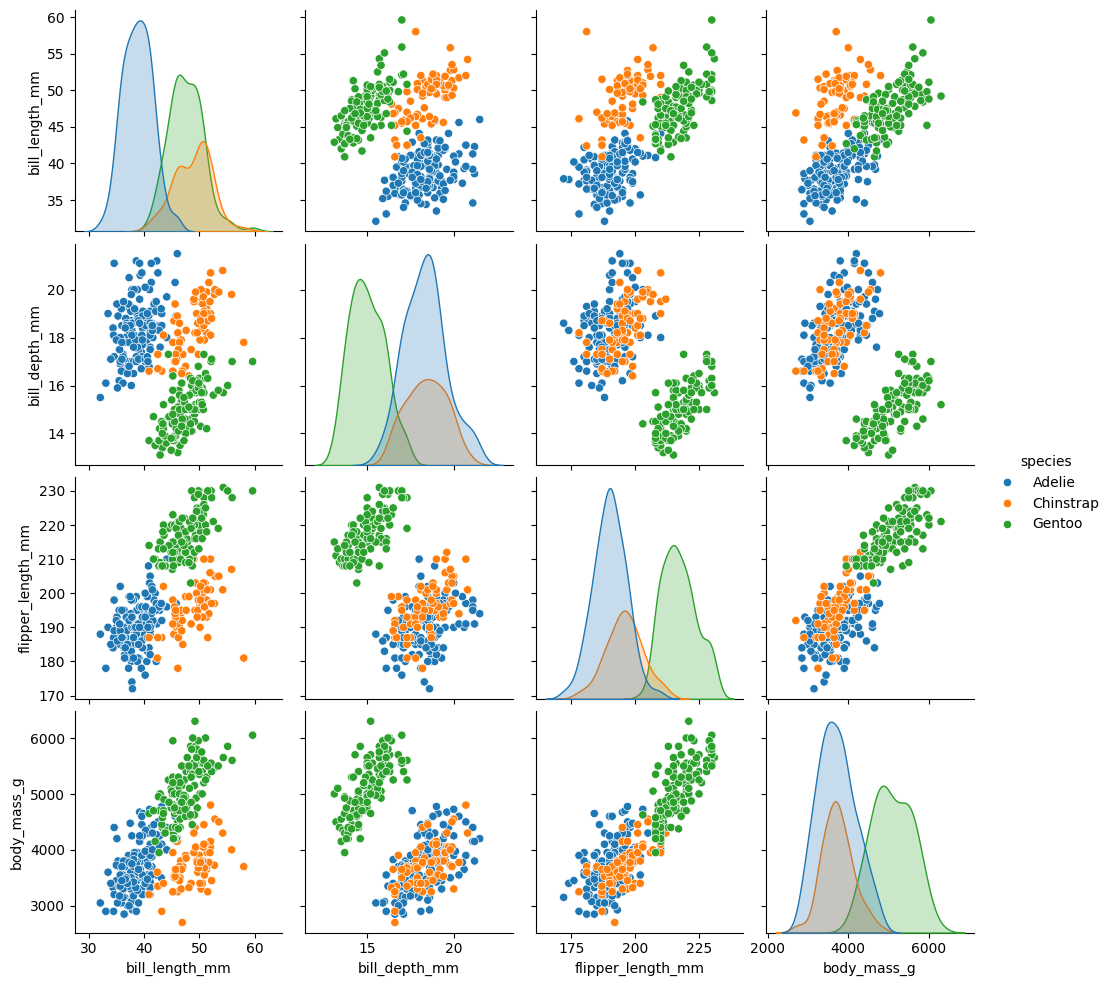

In [3]:
sns.pairplot(df, hue='species');
plt.show()

Hmm... lets take a close look at body mass vs bill length.... that seems really promising!!

Let's imagine what it would be like to use k-Nearest Neighbors on only those two inputs... it might be enough to make things predict well!

In [4]:
# what we want to predict
y = df['species']
# the data we will predict from
X = df[['bill_length_mm','body_mass_g']]

X

,bill_length_mm,body_mass_g
0,39.1,3750.0
1,39.5,3800.0
2,40.3,3250.0
4,36.7,3450.0
5,39.3,3650.0
...,...,...
338,47.2,4925.0
340,46.8,4850.0
341,50.4,5750.0
342,45.2,5200.0


UGH!!! the vector difference $\mathbf{x}_{new} -  \mathbf{x}_{i}$ is going to be absolutely dominated by body mass... it's two orders of magnitude bigger than bill length!

We may not want that!  From the scatterplot it looks like both variables are equally contibuting to understanding species.

We need to normalize the data so each variable is a z-scored version of itself... that means both variables will now be on roughly the same order of magnitued (about -3 to 3).  There are in fact many diffrerent kinds of normalization that could work here!  Take a look at this list: https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing

In [5]:
### YOUR CODE HERE
# import and instantiate a standard scaler
# assign the scaler to preproc
from sklearn.preprocessing import StandardScaler

preproc = StandardScaler()

preproc.fit(X)
scaled_data = preproc.transform(X)
X['bill_length_mm'] = scaled_data[:,0]
X['body_mass_g'] = scaled_data[:,1]

X

# some things to note here... we could just use scaled_data instead of stuffing
# the results back into the dataframe X... I'm just doing this so we can keep
# the column labels intact... scaled_data is a numpy ndarray without those labels
# sklearn will accept numpy arrays or pandas dataframes/series or any other iterable
# as input, so use whatever you want

,bill_length_mm,body_mass_g
0,-0.896042,-0.568475
1,-0.822788,-0.506286
2,-0.676280,-1.190361
4,-1.335566,-0.941606
5,-0.859415,-0.692852
...,...,...
338,0.587352,0.892957
340,0.514098,0.799674
341,1.173384,1.919069
342,0.221082,1.234995


The thing we decided to learn above is strictly numerical.  And preprocessing the way we just described is only good for numerical data.

What if we had been interested in categorical data? For categorical data inputs we usually wish to use a one-hot encoding.

One-hotting a single categorical variable that has N possible categories makes a vector representation that is N long. Because one-hot assumes each category is mutually exclusive with every other category, only one of those N category holders is allowed to be non-zero.

Why use one-hot encoding?  This eliminates unwanted "fake relationships" in categorical data that a different encoding might cause an ML system to learn.

Imagine we have categories like (red, blue, green). There is no ordinal relationship here... red is not > blue, nor is blue > green.  But if we turned (red, blue, green) into a representation like (3, 2, 1) that is exactly what our ML system would learn. Even worse, it would be more likely to confuse blue and green than red and green... because blue minus green is smaller than red minus green.

One hot eliminates this because the 3 long vectors representing each color [1, 0, 0], [0, 1,0], and [0, 0, 0] are orthogonal (unrelated).

In [ ]:
### YOUR CODE HERE
# import and instantiate a one hot encoder
# assign the encoder to catxform

onehot = catxform.fit_transform(df[['island','sex']])
print(df[['island','sex']])
print(onehot.todense())

# there are 3 different islands, so 3 columns get used to encode which island
# only 1 of those 3 columns can be "hot" (non-zero) for each penguin
# likewise there are 2 different sexes recorded here, so 2 columns get used

```python
# Or use this ALTERNATIVE METHOD direct from pandas
pd.get_dummies(df, columns=['island','sex'], dtype=int)
```
Which One Hot method should you use, since there are two to choose from?
- Pro pandas: it dumps out the output as a dataframe without you needing to do anything to integrate the one hot columns with the rest of the data
- Pro sklearn: it uses the .fit() and .transform() methods so you can put it into a sklearn Pipeline... a pipeline lets you make a single ML algorithm with many steps e.g., OneHot then StandardScaler, then PCA, then kNN as a single .fit() call

anyway we're not going to use categorical data right now, so lets stick to the numerical data we did above

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

pclassifier = KNeighborsClassifier(n_neighbors=15)

pclassifier.fit(X,y)
predicted = pclassifier.predict(X)

print(classification_report(y,predicted))

cm = confusion_matrix(y,predicted)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show();

This result shows us that with just 2 variables we can get to 95% accuracy!

BUT note this is TRAINING SET accuracy... something of limited use in understanding how well this classifier will generalize.

Let's figure out how to make a training set/test set



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y,
                                                    test_size=0.3,
                                                    random_state=2015)

print('training/test set sizes')
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print()

pclassifier = KNeighborsClassifier(n_neighbors=15)

pclassifier.fit(X_train, y_train)
predicted_train = pclassifier.predict(X_train)
predicted_test = pclassifier.predict(X_test)

print('training set performance')
print(classification_report(y_train,predicted_train))
print()
print('test set performance')
print(classification_report(y_test,predicted_test))
print()
print('test set confusion matrix')
cm = confusion_matrix(y_test,predicted_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show();

Well what if instead of train/test, we do cross validation?

In [ ]:
from sklearn.model_selection import cross_val_predict

print('lets do 5 fold cross validation...')
X_xval, X_test, y_xval, y_test = train_test_split( X, y,
                                                  test_size=0.3,
                                                  random_state=2015)

print('xval/test set sizes')
print(X_xval.shape, X_test.shape, y_xval.shape, y_test.shape)
print()

pclassifier = KNeighborsClassifier(n_neighbors=15)

predicted_xval = cross_val_predict(pclassifier, X_xval, y_xval, cv=5)
predicted_test = pclassifier.fit(X_xval,y_xval).predict(X_test)

print('xval performance')
print(classification_report(y_xval,predicted_xval))
print()
print('test set performance')
print(classification_report(y_test,predicted_test))
print()
print('test set confusion matrix')
cm = confusion_matrix(y_test,predicted_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show();

This is nice and all, but its only a single hyperparameter setting (`n_neighbors=15`). Cross-validation is _most_ useful for looking among several different hyperparmeter settings and seeing which is the BEST possible.

Now we could imagine doing this in a loop, something like
```python
valid_performance = []
for k in [3, 5, 7, 9, 11, 15, 17, 19, 21]:
    pclassifier = KNeighborsClassifier(n_neighbors=k)
    valid_performance.append( cross_val_predict(pclassifier, X_xval, y_xval, cv=5) )
```
and then refit the BEST hyperparameter setting classifier on all of the xval data set for and check performance on test set.

But that's annoying and requires some actual programming.  Surely there is a one-liner solution which already wrapped all this logic up neatly?  *spoiler, there is*

In [ ]:
from sklearn.model_selection import GridSearchCV

print('lets do grid search using 5 fold cross validation... and this time lets use all the measurements not just the best two')
X = df[['bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g']]
y = df['species']

preproc = StandardScaler()

preproc.fit(X)
scaled_data = preproc.transform(X)
X['bill_length_mm'] = scaled_data[:,0]
X['bill_depth_mm'] = scaled_data[:,1]
X['flipper_length_mm'] = scaled_data[:,2]
X['body_mass_g'] = scaled_data[:,3]

X_xval, X_test, y_xval, y_test = train_test_split( X, y, test_size=0.3, random_state=2015)

print('xval/test set sizes')
print(X_xval.shape, X_test.shape, y_xval.shape, y_test.shape)
print()

# note we don't need to put n_neighbors argument here on instantiation :)
pclassifier = KNeighborsClassifier()
# because we will be passing in n_neighbors values to the search function
params = { 'n_neighbors':[1,3,5,7,9,11,13,15]}

searcher = GridSearchCV(pclassifier, param_grid=params, cv=5)

# at this point we run a bunch of cross validations
searcher.fit(X_xval, y_xval)



In [ ]:
# a fitted set of cvs, one for each param set in the grid
searcher.cv_results_

In [ ]:
# you can match this up with mean_test_score above
searcher.best_params_

In [ ]:
# searcher, when used as a classifier, uses the best_params_ refit on all the xval data by default
predicted_test = searcher.fit(X_xval,y_xval).predict(X_test)


print('test set performance')
print(classification_report(y_test,predicted_test))
print()
print('test set confusion matrix')
cm = confusion_matrix(y_test,predicted_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show();

## Support Vector Machines: Maximizing the *Margin*

Support vector machines are another ML technique

The intuition is this: rather than simply drawing a zero-width line between the classes, we can draw around each line a *margin* of some width, up to the nearest point.
Here is an example of how this might look:

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)

xfit = np.linspace(-1, 3.5)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, s=75);

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5)
plt.show();

In support vector machines, the line that maximizes this margin is the one we will choose as the optimal model.
Support vector machines are an example of such a *maximum margin* estimator.

### Fitting a support vector machine

Let's see the result of an actual fit to this data: we will use Scikit-Learn's support vector classifier to train an SVM model on this data.
For the time being, we will use a linear kernel and set the ``C`` parameter to a very large number (we'll discuss the meaning of these in more depth momentarily).

In [ ]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

In [ ]:
dir(model)

To better visualize what's happening here, let's create a quick convenience function that will plot SVM decision boundaries for us:

In [ ]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=3, facecolors='none', edgecolor='k');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

In [ ]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, s=75);

plot_svc_decision_function(model)
plt.show();

This is the dividing line that maximizes the margin between the two sets of points.
Notice that a few of the training points just touch the margin: they are indicated by the black circles in this figure.
These points are the pivotal elements of this fit, and are known as the *support vectors*, and give the algorithm its name.
In Scikit-Learn, the identity of these points are stored in the ``support_vectors_`` attribute of the classifier:

In [ ]:
model.support_vectors_

A key to this classifier's success is that for the fit, only the position of the support vectors matter; any points further from the margin which are on the correct side do not modify the fit!
Technically, this is because these points do not contribute to the loss function used to fit the model, so their position and number do not matter so long as they do not cross the margin.

We can see this, for example, if we plot the model learned from the first 60 points and first 120 points of this dataset:

In [ ]:
%matplotlib inline

def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, s=75, ax=ax)
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 3, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [30, 60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))
plt.show();

In the left panel, we see the model and the support vectors for just 10 training points, in the middle we see  60 training points and on the right panel 120 points.  While going from 30 to 60 caused changes, going from 60 to 120 did not becuase the support vectors (the points on the margin line) had not changed.

This insensitivity to the exact behavior of distant points is one of the strengths of the SVM model.

### Beyond linear boundaries: Kernel SVM

Where SVM becomes extremely powerful is when it is combined with *kernels*.
We have seen a version of kernels before: Remember polynomial features from the regression lectures?  

There we projected our data into higher-dimensional space defined by polynomials functions, and thereby were able to fit for nonlinear relationships with a linear regression.

In SVM models, we can use a version of the same idea.
To motivate the need for kernels, let's look at some data that is not linearly separable:

In [ ]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, s=75);
plt.xlabel('x1')
plt.ylabel('x2')
plt.show();
#plot_svc_decision_function(clf, plot_support=False);

It is clear that no linear discrimination will *ever* be able to separate this data.

One simple projection we could use would be to compute a *radial basis function* centered on the middle clump:

In [ ]:
phi = np.exp(-(X ** 2).sum(1))

Adding phi as a 3rd dimension gives us this:

In [ ]:
from mpl_toolkits import mplot3d
from matplotlib.colors import ListedColormap
cmap = ListedColormap(sns.color_palette()[:2])

ax = plt.subplot(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], phi, c=y, s=7, cmap=cmap)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('$\phi(\mathbf{x})_3$');
plt.show();

We can see that with this additional dimension, the data becomes trivially linearly separable, by drawing a separating plane at, say, *phi*=0.7.

Here we had to choose and carefully tune our projection: if we had not centered our radial basis function in the right location, we would not have seen such clean, linearly separable results.
In general, the need to make such a choice is a problem: we would like to somehow automatically find the best basis functions to use.

One strategy to this end is to compute a basis function centered at *every* point in the dataset, and let the SVM algorithm sift through the results.
This type of basis function transformation is known as a *kernel transformation*, as it is based on a similarity relationship (or kernel) between each pair of points.

A potential problem with this strategy—projecting $N$ points into $N$ dimensions—is that it might become very computationally intensive as $N$ grows large.
However, because of a neat little procedure known as the [*kernel trick*](https://en.wikipedia.org/wiki/Kernel_trick), a fit on kernel-transformed data can be done implicitly—that is, without ever building the full $N$-dimensional representation of the kernel projection!
This kernel trick is built into the SVM, and is one of the reasons the method is so powerful.

In Scikit-Learn, we can apply kernelized SVM simply by changing our linear kernel to an RBF (radial basis function) kernel, using the ``kernel`` model hyperparameter:

In [ ]:
clf = SVC(kernel='poly', C=1)
clf.fit(X, y)

In [ ]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, s=75)
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none', edgecolor='k');
plt.show();

Using this kernelized support vector machine, we learn a suitable nonlinear decision boundary.
This kernel transformation strategy is used often in machine learning to turn fast linear methods into fast nonlinear methods, especially for models in which the kernel trick can be used.

### Tuning the SVM: Softening Margins

Our discussion thus far has centered around very clean datasets, in which a perfect decision boundary exists.
But what if your data has some amount of overlap?
For example, you may have data like this:

In [ ]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, s=75);
plt.show();

To handle this case, the SVM implementation has a bit of a fudge-factor which "softens" the margin: that is, it allows some of the points to creep into the margin if that allows a better fit.
The hardness of the margin is controlled by a tuning parameter, most often known as $C$.
For very large $C$, the margin is hard, and points cannot lie in it.
For smaller $C$, the margin is softer, and can grow to encompass some points.

The plot shown below gives a visual picture of how a changing $C$ parameter affects the final fit, via the softening of the margin:

In [ ]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, s=75, ax=axi)
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none', edgecolor='k');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

plt.show();

The optimal value of the $C$ parameter will depend on your dataset, and should be tuned using cross-validation or a similar model selection procedure.


In fact in general we would want to do model selection on all the hyperparameters of the SVM... $C$, what kernel to use, and whatever hyperparameters are unique to each kernel like polynomial order in $\phi$.

In fact sklearn gives us a powerful tool to do exactly this. Which I will demonstrate below.

If you're actually following us all the way to this point you are getting into the territory of COGS118A, rather than COGS 108.  So don't worry too much if you feel like you're struggling to understand... this is advanced stuff


But the code below will provide you a template for doing complex model and feature selection using sklearn.  Something that may be useful to your projects :)

Please be careful... this is a template, not something you can necessarily copy/paste for your own data.  You will need to understand how each element works, and how your data might need something different.

In [ ]:
# NOTE: this will take around 2-3 minutes to run

from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV


# what we want to predict
y = df['species']
# the data we will predict from... note that we will include SEX
# because penguin sex is actually pretty important in their size measurements
X = df.drop(columns=['island','species'])

# sex is a categorical variable... it needs to be one hot encoded!
# we know from before that we need to z-score the numeric variables

# here we setup a way to transform the categorical variables into one hot,
# and to z-score the numeric variables.... completely automatically!!
# remember how we had to do this with a bunch of different
# steps manually the last time around??
# if you'd like to understand how to do this more generally
# search the sklearn docs for ColumnTransformer!
numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)

numerical_columns = numerical_columns_selector(X)
categorical_columns = categorical_columns_selector(X)

onehot = OneHotEncoder()
scaler = StandardScaler()

preprocessor = ColumnTransformer([
    ('onehot', onehot, categorical_columns),
    ('zscore', scaler, numerical_columns)])


# Create a pipeline
# a pipeline puts together two (or 3 or however many) steps into one sklearn
# estimator. That means we can use pipe instead of svc in any xval or grid search
# and get the preprocessing done for us in the same step
pipe = Pipeline([('make_features', preprocessor),
                 ('classifier', SVC())])

# SVM have very different hyperparameters depending on which kernel
# potential hyperparams are gamma, coef0, degree and kernel.
# here <x,x'> and ||x-x'|| are similarities between two vectors x,x'
# linear kernel:     <x,x'>  [no hyperparams]
# poly kernel:       ( gamma * <x,x'> + coef0 )^degree
# rbf kernel:        exp( - gamma * ||x-x'||^2 )
# sigmoid kernel:    tanh( gamma * <x,x'> + coef0 )

# so how can we search using only using hypers appropriate for each kernel?
# like this...make a list of different search spaces you want to execute
search_space = [{'classifier__kernel': ['linear'],
                 'classifier__C': np.logspace(-3, 2, 11) #11 steps between 10^-3 to 10^2
                },
                {'classifier__kernel': ['poly'],
                 'classifier__gamma': np.logspace(-3, 2, 11),
                 'classifier__degree': range(2,14),
                 # NOPE... this isnt often important 'classifier__coef0': np.logspace(-3, 2, 11),
                 'classifier__C': np.logspace(-3, 2, 11)
                },
                {'classifier__kernel': ['rbf'],
                 'classifier__gamma': np.logspace(-3, 2, 11),
                 'classifier__C': np.logspace(-3, 2, 11)
                },
                ]



# Create a grid search object to find the best model
best_model = GridSearchCV(pipe, search_space, cv=5, verbose=1)
# play with different verbose=??

# now lets split off some of our data for testing set...
# the rest will be used for cross validation
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25, random_state=101)


# Fit grid search
%time best_model.fit(X_train, y_train)




In [ ]:
# lets find out how well we do on the test set...
print(best_model.best_params_)
best_model.fit(X_train, y_train)
yhat = best_model.predict(X_test)
print(classification_report(y_test, yhat))
ConfusionMatrixDisplay.from_predictions(y_test, yhat);
plt.show();

Now you have the basic ingredients for the ML recipe, something that produce machine learning systems that don't overfit
- Data splitting into train, validate and test sets (`train_test_split()`, etc)
- Preprocessing of inputs to make learning more reliable  (`StandardScaler(), OneHotEncoder()`, etc)
- Metrics to measure performance (accuracy, precision, recall, MSE, etc)
- Model selection methods and important helper functions for effortless operation (`GridSearchCV(), Pipeline()`, etc)


### A frequent problem to watch out for

But even following this recipie you can go wrong.  One important issue that can arise is if there is either a huge class imbalance (cancer detection!) or groups in your data that you want to generalize across (what if there is a difference in measurements between penguins of the same species on different islands?)

Here is an important scikit tutorial on how to deal with either situation through use of Stratified or Grouped (or both) cross-validators https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html


So here's a challenge for you... lets try one final version of the penguin species prediction but note that
1. Chinstrap penguins are a much smaller number of samples... cross validation may work better if we stratify.  If stratified k-fold works better for this task then without it you can guess that some folds of cross-validation were having too few / too many Chinstraps
2. Islands may have an effect on growth, so lets see if we could successfully predict across island by grouping on that.  If we get worse with grouping then islands have a clear affect on growth, if we don't get worse on grouping then they probably have no effect


This is totally up to you, you program it free form. And then tell us about the results in the following google form check-in.

https://forms.gle/D1JfyLaR1VJMxJno9